## オブジェクト指向

In [132]:
import random
import matplotlib.pyplot as plt

class RandomWoker:
    def __init__(self, speed = 1.0):
        self.position = 0.0 # 現在地
        self.speed = speed # ランダムウォークする移動量
        self.trajectory = [self.position] # ランダムウォークの軌跡

    def walk(self):
        # ランダムに移動するロジック（1 or -1）
        n = random.choice([-1, 1])
        # 移動
        self.position += n * self.speed
        # 軌跡に現在地を追加
        self.trajectory.append(self.position)

    def plot_trajectory(self):
        # ランダムウォークした軌跡をグラフ化する
        plt.figure(figsize=(6, 4))
        plt.plot(self.trajectory, marker='o')
        plt.title(f'Random Walk Trajectory (speed = {self.speed})', fontsize = 14)
        plt.xlabel('Step', fontsize = 12)
        plt.ylabel('Position', fontsize = 12)
        plt.show()


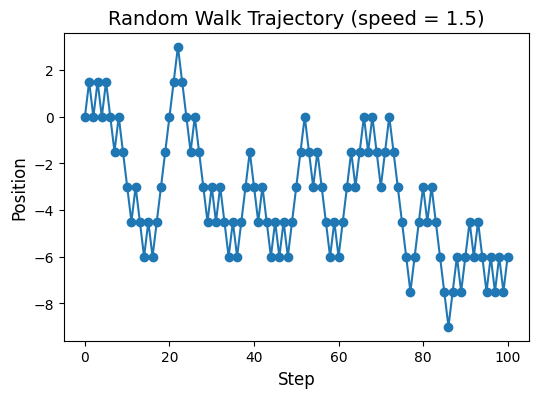

In [133]:
speed = 1.5
rw = RandomWoker(speed)
# ランダムウォークを100ステップ行う
for _ in range(100):
    rw.walk()
# ランダムウォークの軌跡をプロットする
rw.plot_trajectory()

## 格子上での進化ゲーム

In [134]:
class Agent:
    def __init__(self):
        # 協力か非協力かをランダムに決定
        self.strategy = random.choice(['C', 'D']) # C: 協力, D: 非協力
        # 更新後に使う戦略
        self.next_strategy = None
        # 世代ごとのリセット
        self.reset()

    def reset(self) -> None:
        self.payoff = 0 # 利得の初期化

    def get_payoff(self, p: float) -> None:
        self.payoff += p

    def find_next_strategy(self, neighbors: list[list]) -> None:
        """
        """
        list_with_me = neighbors + [self]
        # 同じ利得がいる場合に備えて、参照額をシャッフル
        random.shuffle(list_with_me)
        # 最も利得が高いエージェントを見つける
        max_agent = list_with_me[0] # 初期値
        for i in range(1, len(list_with_me)):
            a = list_with_me[i]
            if a.payoff > max_agent.payoff:
                max_agent = a
        # 最も利得が高いエージェントの戦略をメモ
        self.next_strategy = max_agent.strategy

    def update_strategy(self) -> None:
        self.strategy = self.next_strategy

In [135]:
class EvolGame:
    def __init__(self, L: int=50):
        # 格子の一辺の長さ
        self.L = L
        # ゲームの利得行列
        self.pmatrix = {
            ('C', 'C'): 5, # 相互協力
            ('C', 'D'): 0, # 自分が協力, 相手が非協力
            ('D', 'C'): 6, # 自分が非協力, 相手が協力
            ('D', 'D'): 1  # 相互非協力
        }
        # 格子上のエージェントのリスト
        self.agent_list = [[Agent() for _ in range(L)] for _ in range(L)]

    # エージェントの利得をリセット (0) する
    def reset(self) -> None:
        for i in self.agent_list:
            for a in i:
                a.reset()

    # ゲーム（利得の計算）
    def expFn(self) -> None:
        # 各エージェントの処理
        for i, l in enumerate(self.agent_list):
            for j, focal in enumerate(l):
                # エージェント focal の処理

                def play_with_neighbor(focal: Agent, opp: Agent) -> None:
                    """
                    互いの戦略からゲームの利得を得て、focal (自分) と opp (相手) に利得を追加する
                    """
                    p_focal = self.pmatrix[(focal.strategy, opp.strategy)]
                    p_opp = self.pmatrix[(opp.strategy, focal.strategy)]

                    # focal へ利得を追加
                    focal.get_payoff(p_focal)
                    # opp へ利得を追加
                    opp.get_payoff(p_opp)
                
                # 左隣のエージェント
                opp1 = self.agent_list[i][j-1]
                play_with_neighbor(focal, opp1)

                # 上隣のエージェント
                opp2 = self.agent_list[i-1][j]
                play_with_neighbor(focal, opp2)

    # 全エージェントの戦略を更新
    def update_strategy(self) -> None:
        # それぞれのエージェントの処理
        for i, l in enumerate(self.agent_list):
            for j, focal in enumerate(l):


                neighbors = [
                    self.agent_list[i-1][j], # 上
                    self.agent_list[i][j-1], # 左
                    # -L で末尾からアクセスする（out of range を防ぐ）
                    self.agent_list[i+1-self.L][j], # 下
                    self.agent_list[i][j+1-self.L] # 右
                ]

                # 隣人の戦略の中で最も利得の高い戦略を見つける
                focal.find_next_strategy(neighbors)

        # 全エージェントの戦略を更新する
        for l in self.agent_list:
            for a in l:
                a.update_strategy()

********** 100%


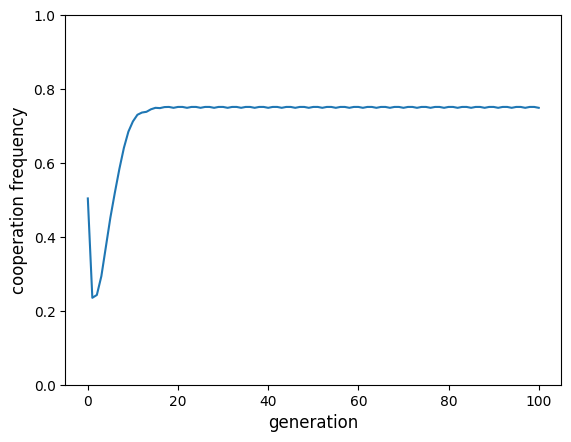

In [136]:
def calc_C_frequency(agent_list: list[list[Agent]]) -> float:
    # 協力者人数
    nC = 0
    for l in agent_list:
        for focal in l:
            if focal.strategy == 'C':
                nC += 1

    # エージェント総数（L×L）で割って協力者割合を返す
    return nC / (len(agent_list) * len(agent_list[0]))

def simulate(Tmax = 100, L = 50) -> None:
    game = EvolGame(L) # ゲームの初期化
    # 協力者割合を記録
    fC_list = [calc_C_frequency(game.agent_list)]

    # 世代を Tmax 回繰り返す
    for i in range(Tmax):
        game.reset() # エージェントの利得をリセット
        game.expFn() # ゲームを実施
        game.update_strategy() # 戦略を更新

        fC_list.append(calc_C_frequency(game.agent_list)) # 協力者割合を記録

        # 進捗確認用のバーを表示
        t = Tmax / 10
        if (i+1)%t == 0:
            print("*"*int((i+1)/t) + 
                "_"*(10-int((i+1)/t)), 
                f"{int((i+1)/Tmax*100):3d}%",  
                end='\r' if (i+1)<Tmax else '\n')
    
    return fC_list

def plot_fC(fC_list: list[float]) -> None:
    # 協力者割合の推移をグラフ化する
    plt.ylim(0,1)
    plt.xlabel('generation', fontsize=12)
    plt.ylabel('cooperation frequency', fontsize=12)
    plt.plot(fC_list)

fC_list = simulate(Tmax=100, L=50)
plot_fC(fC_list)

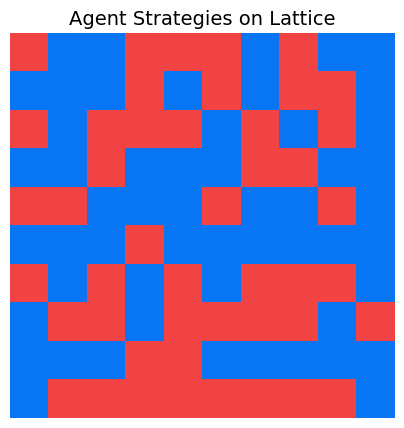

Generation 2


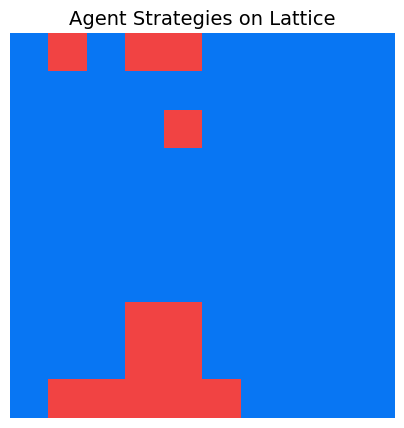

Generation 4


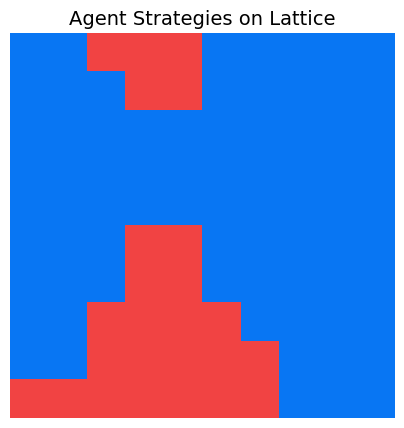

Generation 6


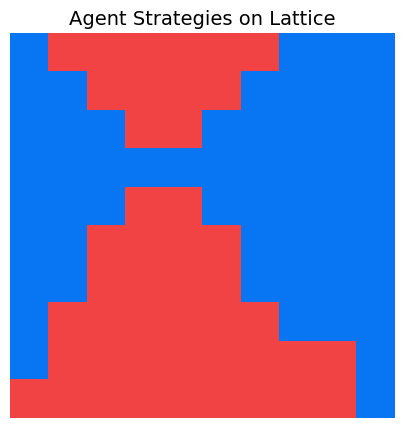

Generation 8


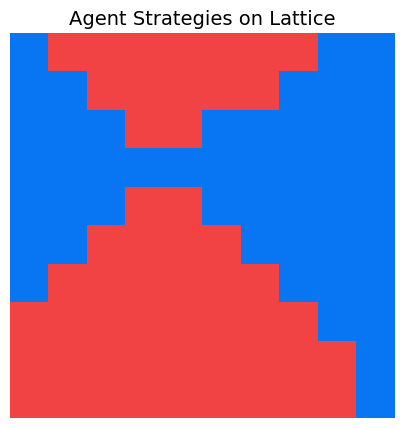

Generation 10


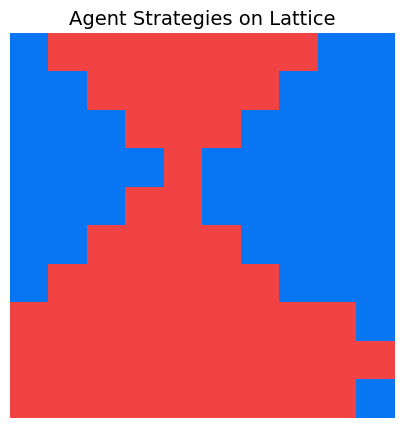

In [137]:
from matplotlib.colors import ListedColormap

def plot_lattice(agent_list: list[list[Agent]]) -> None:
    # 格子上のエージェントの戦略を色で表現するための2次元リストを作成
    strategy_grid = [[1 if a.strategy == 'C' else 0 for a in l] for l in agent_list]

    # 格子上のエージェントの戦略を色で表現するためのグラフを作成

    soft_cmap = ListedColormap(["#0876f3", "#f14343"])
    plt.figure(figsize=(5, 5))
    plt.imshow(strategy_grid, cmap=soft_cmap, vmin=0, vmax=1)
    plt.title('Agent Strategies on Lattice', fontsize = 14)
    plt.axis('off') # 軸を非表示にする
    plt.show()

def simulate(Tmax = 10, L = 10) -> None:
    game = EvolGame(L)
    # 協力戦略の割合を記録するリスト
    plot_lattice(game.agent_list) # 初期状態の格子をプロットする
    for i in range(Tmax):
        game.reset() # エージェントの利得をリセットする
        game.expFn() # # ゲームの利得を計算する
        game.update_strategy() # 全エージェントの戦略を更新する
        # 10世代ごとに格子をプロットする
        if (i+1) % 2 == 0:
            print(f'Generation {i+1}')
            plot_lattice(game.agent_list)
    
simulate()

### シミュレーション結果

```python
('C', 'C'): 5, # 相互協力
('C', 'D'): 0, # 自分が協力, 相手が非協力
('D', 'C'): 6, # 自分が非協力, 相手が協力
('D', 'D'): 1  # 相互非協力
```

## 協力の利得
- 周り4人が協力者
    ・ 4人の協力者から5ずつもらえるので、20
- 1人が非協力者, 3人が協力者
    ・ 1人の非協力者から0もらえるので、0
    ・ 3人の協力者から5ずつもらえるので、15
    ・ 合計15
- 2人が非協力者, 2人が協力者
    ・ 2人の非協力者から0もらえるので、0
    ・ 2人の協力者から5ずつもらえるので、10
    ・ 合計10
- 3人が非協力者, 1人が協力者
    ・ 3人の非協力者から0もらえるので、0
    ・ 1人の協力者から5もらえるので、5
    ・ 合計5
- 周り4人が非協力者
    ・ 4人の非協力者から0もらえるので、0

## 非協力の利得
- 周り4人が協力者
    ・ 4人の協力者から6ずつもらえるので、24
- 1人が非協力者, 3人が協力者
    ・ 1人の非協力者から1もらえるので、1
    ・ 3人の協力者から6ずつもらえるので、18
    ・ 合計19
- 2人が非協力者, 2人が協力者
    ・ 2人の非協力者から1ずつもらえるので、2
    ・ 2人の協力者から6ずつもらえるので、12
    ・ 合計14
- 3人が非協力者, 1人が協力者
    ・ 3人の非協力者から1ずつもらえるので、3
    ・ 1人の協力者から6もらえるので、6
    ・ 合計9
- 周り4人が非協力者
    ・ 4人の非協力者から1ずつもらえるので、4

どちらの戦略も、**協力者**が多いほど利得が増える。ただし、同じ近傍構成なら常に非協力者の方が協力者より高利得である。そのため初期には非協力が広がりやすい。一方で、非協力者が増えて周囲も非協力者ばかりになると、非協力者同士の利得は低くなる。そこで、初期のランダム配置の中で形成された協力者集団が一定規模で生き残ると、その内部では高い利得を維持できるため、周囲の低利得な非協力者より有利になり、集団として拡大していく可能性がある。